In [54]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [55]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np



bhp = yf.download("BHP.AX", start="2005-01-01")
bhp.to_csv("data/bhp_prices.csv")

/var/folders/5l/hdkvhlj11x73wsv279bv3wfh0000gn/T/ipykernel_1699/2766399077.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bhp = yf.download("BHP.AX", start="2005-01-01")
[*********************100%***********************]  1 of 1 completed


In [56]:
bhp.info()
bhp.head()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5243 entries, 2005-01-04 to 2025-09-25
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, BHP.AX)   5243 non-null   float64
 1   (High, BHP.AX)    5243 non-null   float64
 2   (Low, BHP.AX)     5243 non-null   float64
 3   (Open, BHP.AX)    5243 non-null   float64
 4   (Volume, BHP.AX)  5243 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 245.8 KB


Price,Close,High,Low,Open,Volume
Ticker,BHP.AX,BHP.AX,BHP.AX,BHP.AX,BHP.AX
Date,,,,,
2005-01-04,4.687746,4.718708,4.678457,4.706324,9577292
2005-01-05,4.641300,4.641300,4.591760,4.597953,17338086
2005-01-06,4.653685,4.669167,4.604145,4.607241,10893452
2005-01-07,4.706321,4.727994,4.675358,4.690839,11839128
2005-01-10,4.715612,4.737286,4.690842,4.703227,8525514


In [57]:
bhp.isna().sum()

Price   Ticker
Close   BHP.AX    0
High    BHP.AX    0
Low     BHP.AX    0
Open    BHP.AX    0
Volume  BHP.AX    0
dtype: int64

In [58]:
bhp.dtypes

Price   Ticker
Close   BHP.AX    float64
High    BHP.AX    float64
Low     BHP.AX    float64
Open    BHP.AX    float64
Volume  BHP.AX      int64
dtype: object

In [59]:
bhp['Volume'] = bhp['Volume'].astype(float)


In [60]:
bhp.dtypes

Price   Ticker
Close   BHP.AX    float64
High    BHP.AX    float64
Low     BHP.AX    float64
Open    BHP.AX    float64
Volume  BHP.AX    float64
dtype: object

In [61]:
bhp.duplicated().sum()         
bhp.drop_duplicates(inplace=True)   
bhp.sort_index(inplace=True)      


In [62]:
bhp.head()
bhp.columns = ['Close', 'High', 'Low', 'Open', 'Volume']
bhp.head()
bhp.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5242 entries, 2005-01-04 to 2025-09-25
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5242 non-null   float64
 1   High    5242 non-null   float64
 2   Low     5242 non-null   float64
 3   Open    5242 non-null   float64
 4   Volume  5242 non-null   float64
dtypes: float64(5)
memory usage: 245.7 KB


In [63]:
all_days = pd.date_range(bhp.index.min(), bhp.index.max(), freq="B")
missing_days = all_days.difference(bhp.index)


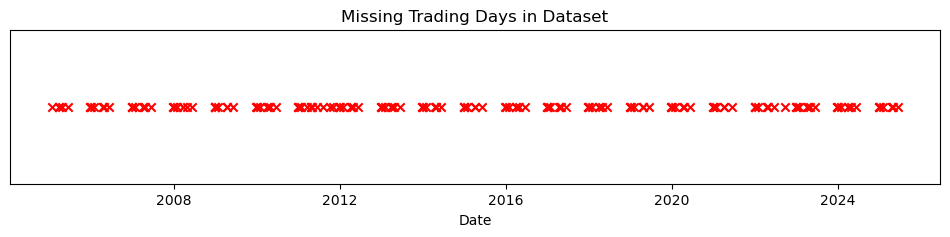

In [64]:
plt.figure(figsize=(12,2))
plt.scatter(missing_days, [1]*len(missing_days), color='red', marker='x')
plt.title("Missing Trading Days in Dataset")
plt.yticks([])
plt.xlabel("Date")
plt.show()

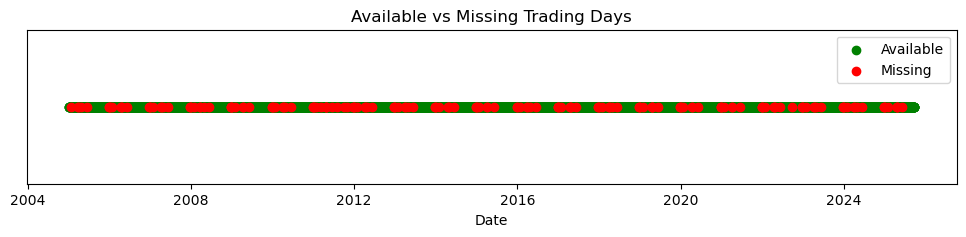

In [65]:
plt.figure(figsize=(12,2))
plt.scatter(bhp.index, [1]*len(bhp.index), color='green', label='Available')
plt.scatter(missing_days, [1]*len(missing_days), color='red', label='Missing')
plt.title("Available vs Missing Trading Days")
plt.yticks([])
plt.xlabel("Date")
plt.legend()
plt.show()


In [66]:
bhp = bhp.reindex(bhp.index.intersection(all_days))

In [67]:
bhp.head()
bhp.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5242 entries, 2005-01-04 to 2025-09-25
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   5242 non-null   float64
 1   High    5242 non-null   float64
 2   Low     5242 non-null   float64
 3   Open    5242 non-null   float64
 4   Volume  5242 non-null   float64
dtypes: float64(5)
memory usage: 245.7 KB


In [68]:
missing_days = all_days.difference(bhp.index)
print(f"Number of missing trading days excluded: {len(missing_days)}")


Number of missing trading days excluded: 166


In [69]:
# Simple daily percentage return
bhp['Return'] = bhp['Close'].pct_change()
# Log return
bhp['LogReturn'] = np.log(bhp['Close'] / bhp['Close'].shift(1))

In [70]:
bhp.head(5)

,Close,High,Low,Open,Volume,Return,LogReturn
2005-01-04,4.687746,4.718708,4.678457,4.706324,9577292.0,NaN,NaN
2005-01-05,4.641300,4.641300,4.591760,4.597953,17338086.0,-0.009908,-0.009957
2005-01-06,4.653685,4.669167,4.604145,4.607241,10893452.0,0.002668,0.002665
2005-01-07,4.706321,4.727994,4.675358,4.690839,11839128.0,0.011311,0.011247
2005-01-10,4.715612,4.737286,4.690842,4.703227,8525514.0,0.001974,0.001972


In [71]:
bhp['Return_lag1'] = bhp['Return'].shift(3)
bhp['Return_lag2'] = bhp['Return'].shift(5)
bhp['Return_lag3'] = bhp['Return'].shift(7)


In [72]:
bhp.head(10)

,Close,High,Low,Open,Volume,Return,LogReturn,Return_lag1,Return_lag2,Return_lag3
2005-01-04,4.687746,4.718708,4.678457,4.706324,9577292.0,NaN,NaN,NaN,NaN,NaN
2005-01-05,4.641300,4.641300,4.591760,4.597953,17338086.0,-0.009908,-0.009957,NaN,NaN,NaN
2005-01-06,4.653685,4.669167,4.604145,4.607241,10893452.0,0.002668,0.002665,NaN,NaN,NaN
2005-01-07,4.706321,4.727994,4.675358,4.690839,11839128.0,0.011311,0.011247,NaN,NaN,NaN
2005-01-10,4.715612,4.737286,4.690842,4.703227,8525514.0,0.001974,0.001972,-0.009908,NaN,NaN
2005-01-11,4.709417,4.752765,4.703224,4.715610,9425972.0,-0.001314,-0.001314,0.002668,NaN,NaN
2005-01-12,4.743478,4.749670,4.697034,4.712515,9468182.0,0.007233,0.007206,0.011311,-0.009908,NaN
2005-01-13,4.743478,4.786826,4.731093,4.771344,10329984.0,0.000000,0.000000,0.001974,0.002668,NaN
2005-01-14,4.765152,4.768248,4.721804,4.737285,7298129.0,0.004569,0.004559,-0.001314,0.011311,-0.009908
2005-01-17,4.873521,4.876617,4.839462,4.861136,12956398.0,0.022742,0.022487,0.007233,0.001974,0.002668


In [73]:
bhp['SMA_5'] = bhp['Close'].rolling(window=5).mean()
bhp['SMA_10'] = bhp['Close'].rolling(window=10).mean()
bhp['EMA_5'] = bhp['Close'].ewm(span=5, adjust=False).mean()


In [74]:
bhp.head(10)

,Close,High,Low,Open,Volume,Return,LogReturn,Return_lag1,Return_lag2,Return_lag3,SMA_5,SMA_10,EMA_5
2005-01-04,4.687746,4.718708,4.678457,4.706324,9577292.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.687746
2005-01-05,4.641300,4.641300,4.591760,4.597953,17338086.0,-0.009908,-0.009957,NaN,NaN,NaN,NaN,NaN,4.672264
2005-01-06,4.653685,4.669167,4.604145,4.607241,10893452.0,0.002668,0.002665,NaN,NaN,NaN,NaN,NaN,4.666071
2005-01-07,4.706321,4.727994,4.675358,4.690839,11839128.0,0.011311,0.011247,NaN,NaN,NaN,NaN,NaN,4.679488
2005-01-10,4.715612,4.737286,4.690842,4.703227,8525514.0,0.001974,0.001972,-0.009908,NaN,NaN,4.680933,NaN,4.691529
2005-01-11,4.709417,4.752765,4.703224,4.715610,9425972.0,-0.001314,-0.001314,0.002668,NaN,NaN,4.685267,NaN,4.697492
2005-01-12,4.743478,4.749670,4.697034,4.712515,9468182.0,0.007233,0.007206,0.011311,-0.009908,NaN,4.705703,NaN,4.712821
2005-01-13,4.743478,4.786826,4.731093,4.771344,10329984.0,0.000000,0.000000,0.001974,0.002668,NaN,4.723661,NaN,4.723040
2005-01-14,4.765152,4.768248,4.721804,4.737285,7298129.0,0.004569,0.004559,-0.001314,0.011311,-0.009908,4.735428,NaN,4.737077
2005-01-17,4.873521,4.876617,4.839462,4.861136,12956398.0,0.022742,0.022487,0.007233,0.001974,0.002668,4.767009,4.723971,4.782559


In [75]:
bhp['Volatility_5'] = bhp['Return'].rolling(window=5).std()
bhp['Volatility_10'] = bhp['Return'].rolling(window=10).std()


In [76]:
bhp.head(10)

,Close,High,Low,Open,Volume,Return,LogReturn,Return_lag1,Return_lag2,Return_lag3,SMA_5,SMA_10,EMA_5,Volatility_5,Volatility_10
2005-01-04,4.687746,4.718708,4.678457,4.706324,9577292.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.687746,NaN,NaN
2005-01-05,4.641300,4.641300,4.591760,4.597953,17338086.0,-0.009908,-0.009957,NaN,NaN,NaN,NaN,NaN,4.672264,NaN,NaN
2005-01-06,4.653685,4.669167,4.604145,4.607241,10893452.0,0.002668,0.002665,NaN,NaN,NaN,NaN,NaN,4.666071,NaN,NaN
2005-01-07,4.706321,4.727994,4.675358,4.690839,11839128.0,0.011311,0.011247,NaN,NaN,NaN,NaN,NaN,4.679488,NaN,NaN
2005-01-10,4.715612,4.737286,4.690842,4.703227,8525514.0,0.001974,0.001972,-0.009908,NaN,NaN,4.680933,NaN,4.691529,NaN,NaN
2005-01-11,4.709417,4.752765,4.703224,4.715610,9425972.0,-0.001314,-0.001314,0.002668,NaN,NaN,4.685267,NaN,4.697492,0.007654,NaN
2005-01-12,4.743478,4.749670,4.697034,4.712515,9468182.0,0.007233,0.007206,0.011311,-0.009908,NaN,4.705703,NaN,4.712821,0.004932,NaN
2005-01-13,4.743478,4.786826,4.731093,4.771344,10329984.0,0.000000,0.000000,0.001974,0.002668,NaN,4.723661,NaN,4.723040,0.005294,NaN
2005-01-14,4.765152,4.768248,4.721804,4.737285,7298129.0,0.004569,0.004559,-0.001314,0.011311,-0.009908,4.735428,NaN,4.737077,0.003455,NaN
2005-01-17,4.873521,4.876617,4.839462,4.861136,12956398.0,0.022742,0.022487,0.007233,0.001974,0.002668,4.767009,4.723971,4.782559,0.009634,NaN


In [77]:
bhp['Volume_change'] = bhp['Volume'].pct_change()
bhp['Volume_SMA_5'] = bhp['Volume'].rolling(5).mean()


In [84]:
bhp.head(10)

,Close,High,Low,Open,Volume,Return,LogReturn,Return_lag1,Return_lag2,Return_lag3,SMA_5,SMA_10,EMA_5,Volatility_5,Volatility_10,Volume_change,Volume_SMA_5,MA50,Volatility
2005-01-18,4.854944,4.938543,4.842559,4.935447,13421297.0,NaN,NaN,0.000000,-0.001314,0.011311,4.796115,4.740691,4.806687,0.010198,0.008932,0.035882,10694798.0,NaN,NaN
2005-01-19,4.895195,4.916870,4.839463,4.892099,12956900.0,0.008291,0.008257,0.004569,0.007233,0.001974,4.826458,4.766080,4.836190,0.010237,0.007648,-0.034601,11392541.6,NaN,NaN
2005-01-20,4.830173,4.858040,4.805403,4.833269,9243129.0,-0.013283,-0.013372,0.022742,0.000000,-0.001314,4.843797,4.783729,4.834184,0.013503,0.009669,-0.286625,11175170.6,NaN,NaN
2005-01-21,4.830173,4.842558,4.805403,4.814692,9667311.0,0.000000,0.000000,-0.003812,0.004569,0.007233,4.856801,4.796114,4.832847,0.013584,0.009345,0.045892,11649007.0,NaN,NaN
2005-01-24,4.938542,4.941638,4.882810,4.895195,12531205.0,0.022436,0.022188,0.008291,0.022742,0.000000,4.869806,4.818407,4.868079,0.013471,0.011233,0.296245,11563968.4,NaN,NaN
2005-01-25,4.960217,5.022142,4.954024,5.006661,13965371.0,0.004389,0.004379,-0.013283,-0.003812,0.004569,4.890860,4.843487,4.898791,0.012966,0.011037,0.114448,11672783.2,NaN,NaN
2005-01-27,5.071681,5.077874,4.975697,4.984986,15690764.0,0.022472,0.022223,0.000000,0.008291,0.022742,4.926157,4.876308,4.956421,0.015368,0.012318,0.123548,12219556.0,NaN,NaN
2005-01-28,5.034527,5.090260,5.019046,5.065489,25191718.0,-0.007326,-0.007353,0.022436,-0.013283,-0.003812,4.967028,4.905413,4.982456,0.013500,0.012967,0.605513,15409273.8,NaN,NaN
2005-01-31,5.037624,5.074779,4.991180,5.000469,11980493.0,0.000615,0.000615,0.004389,0.000000,0.008291,5.008518,4.932660,5.000846,0.013407,0.013077,-0.524427,15871910.2,NaN,NaN
2005-02-01,5.127414,5.139799,5.087163,5.096452,11523944.0,0.017824,0.017667,0.022472,0.022436,-0.013283,5.046292,4.958049,5.043035,0.012325,0.012440,-0.038108,15670458.0,NaN,NaN


In [78]:
bhp.dropna(inplace=True)

In [79]:
bhp.head(10)

,Close,High,Low,Open,Volume,Return,LogReturn,Return_lag1,Return_lag2,Return_lag3,SMA_5,SMA_10,EMA_5,Volatility_5,Volatility_10,Volume_change,Volume_SMA_5
2005-01-18,4.854944,4.938543,4.842559,4.935447,13421297.0,-0.003812,-0.003819,0.000000,-0.001314,0.011311,4.796115,4.740691,4.806687,0.010198,0.008932,0.035882,10694798.0
2005-01-19,4.895195,4.916870,4.839463,4.892099,12956900.0,0.008291,0.008257,0.004569,0.007233,0.001974,4.826458,4.766080,4.836190,0.010237,0.007648,-0.034601,11392541.6
2005-01-20,4.830173,4.858040,4.805403,4.833269,9243129.0,-0.013283,-0.013372,0.022742,0.000000,-0.001314,4.843797,4.783729,4.834184,0.013503,0.009669,-0.286625,11175170.6
2005-01-21,4.830173,4.842558,4.805403,4.814692,9667311.0,0.000000,0.000000,-0.003812,0.004569,0.007233,4.856801,4.796114,4.832847,0.013584,0.009345,0.045892,11649007.0
2005-01-24,4.938542,4.941638,4.882810,4.895195,12531205.0,0.022436,0.022188,0.008291,0.022742,0.000000,4.869806,4.818407,4.868079,0.013471,0.011233,0.296245,11563968.4
2005-01-25,4.960217,5.022142,4.954024,5.006661,13965371.0,0.004389,0.004379,-0.013283,-0.003812,0.004569,4.890860,4.843487,4.898791,0.012966,0.011037,0.114448,11672783.2
2005-01-27,5.071681,5.077874,4.975697,4.984986,15690764.0,0.022472,0.022223,0.000000,0.008291,0.022742,4.926157,4.876308,4.956421,0.015368,0.012318,0.123548,12219556.0
2005-01-28,5.034527,5.090260,5.019046,5.065489,25191718.0,-0.007326,-0.007353,0.022436,-0.013283,-0.003812,4.967028,4.905413,4.982456,0.013500,0.012967,0.605513,15409273.8
2005-01-31,5.037624,5.074779,4.991180,5.000469,11980493.0,0.000615,0.000615,0.004389,0.000000,0.008291,5.008518,4.932660,5.000846,0.013407,0.013077,-0.524427,15871910.2
2005-02-01,5.127414,5.139799,5.087163,5.096452,11523944.0,0.017824,0.017667,0.022472,0.022436,-0.013283,5.046292,4.958049,5.043035,0.012325,0.012440,-0.038108,15670458.0


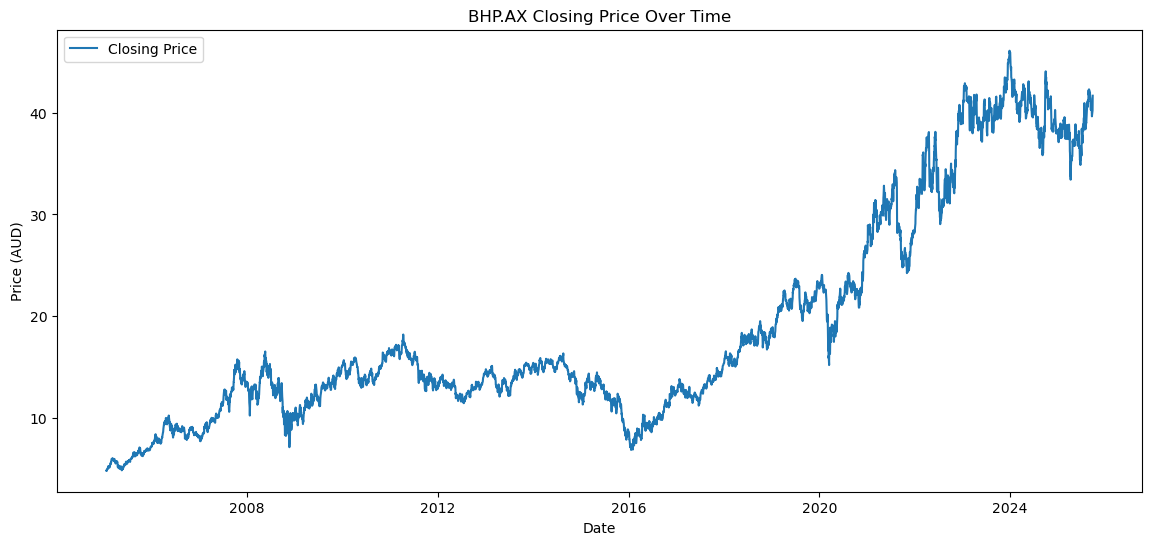

In [80]:
plt.figure(figsize=(14,6))
plt.plot(bhp.index, bhp['Close'], label='Closing Price')
plt.xlabel("Date")
plt.ylabel("Price (AUD)")
plt.title("BHP.AX Closing Price Over Time")
plt.legend()
plt.show()


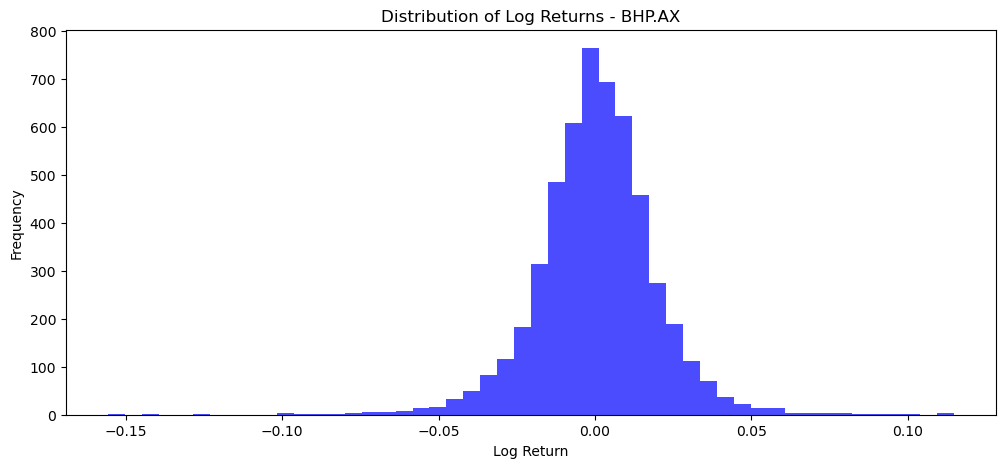

In [82]:
bhp['Return'] = bhp['Close'].pct_change()
bhp['LogReturn'] = np.log(bhp['Close'] / bhp['Close'].shift(1))

plt.figure(figsize=(12,5))
plt.hist(bhp['LogReturn'].dropna(), bins=50, alpha=0.7, color='blue')
plt.title("Distribution of Log Returns - BHP.AX")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.show()


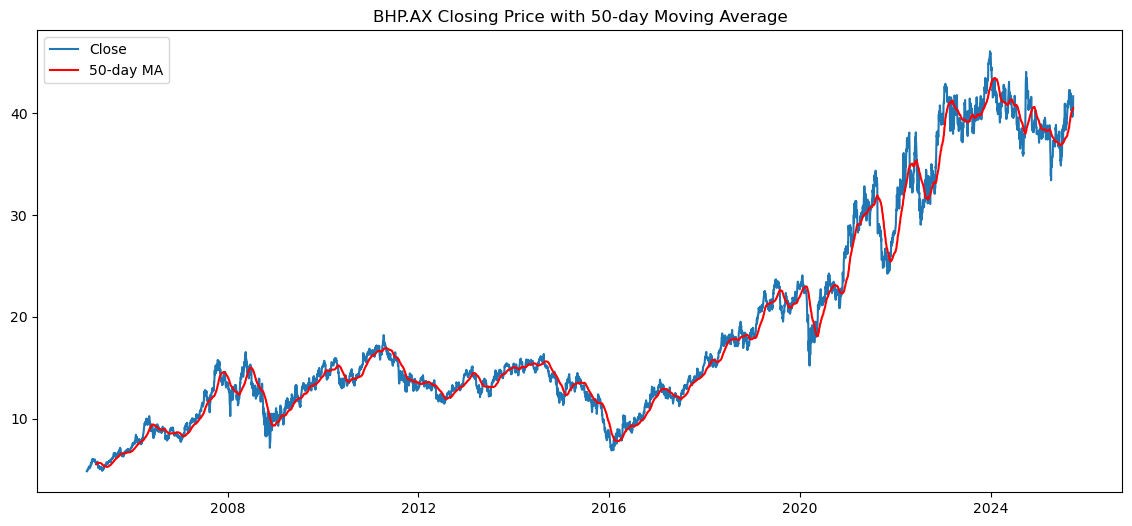

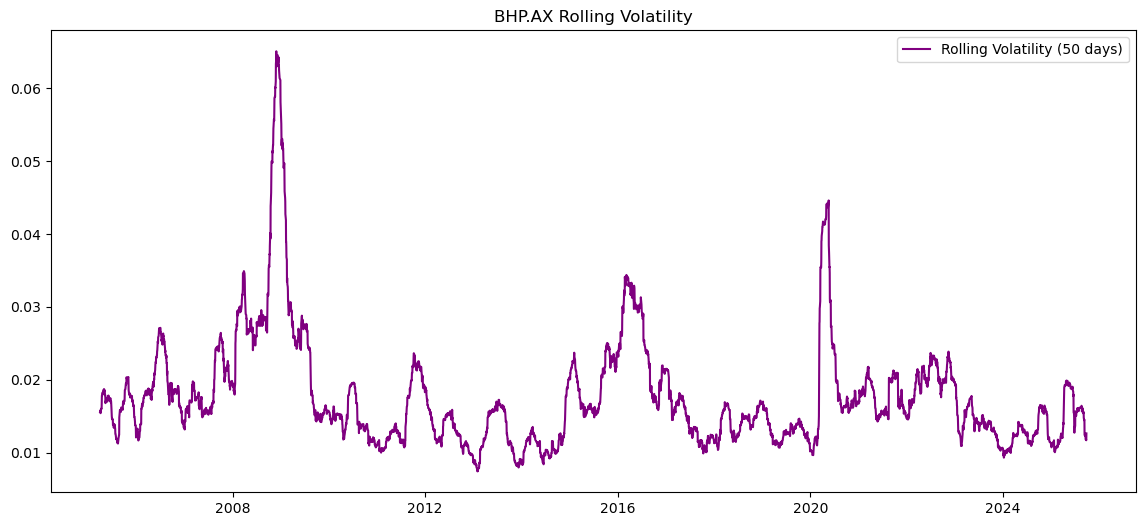

In [83]:
bhp['MA50'] = bhp['Close'].rolling(window=50).mean()
bhp['Volatility'] = bhp['LogReturn'].rolling(window=50).std()

plt.figure(figsize=(14,6))
plt.plot(bhp.index, bhp['Close'], label='Close')
plt.plot(bhp.index, bhp['MA50'], label='50-day MA', color='red')
plt.title("BHP.AX Closing Price with 50-day Moving Average")
plt.legend()
plt.show()

plt.figure(figsize=(14,6))
plt.plot(bhp.index, bhp['Volatility'], color='purple', label='Rolling Volatility (50 days)')
plt.title("BHP.AX Rolling Volatility")
plt.legend()
plt.show()
